Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  Cluster  
0       Iri

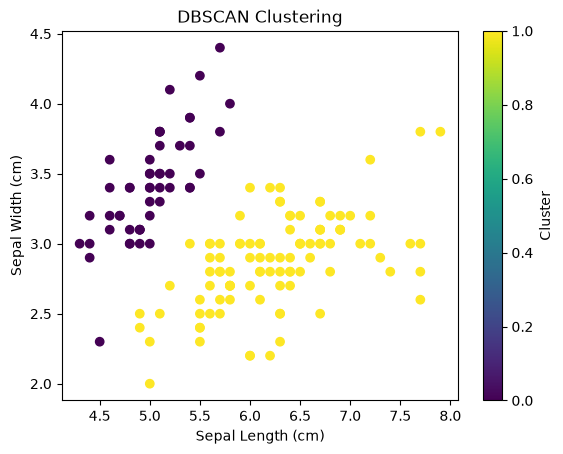

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"C:\Users\dipal\OneDrive\Desktop\Machine Learning\Practical\Iris.csv")

print(data.columns)

X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

model = DBSCAN(eps=1, min_samples=5)

labels = model.fit_predict(X)

data['Cluster'] = labels

print(data)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters: " , n_clusters)
print("Noise points :-  ", list(labels).count(-1))

if n_clusters > 1:
    score = silhouette_score(X, labels)
    print("Silhouette Score: ", score)


plt.scatter(
    data['SepalLengthCm'], 
    data['SepalWidthCm'], 
    c=data['Cluster'], 
    cmap='viridis'
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster')
plt.show()

